torch.Size([571, 6]) torch.Size([571])
torch.Size([571, 6]) torch.Size([571, 1])
torch.Size([143, 6]) torch.Size([143, 1])
Epoch [1/3000], Loss: 1.0202, Test Loss: 0.8566
Epoch [101/3000], Loss: 0.8499, Test Loss: 0.7029
Epoch [201/3000], Loss: 0.6468, Test Loss: 0.6196
Epoch [301/3000], Loss: 0.6040, Test Loss: 0.6146
Epoch [401/3000], Loss: 0.5567, Test Loss: 0.6171
Epoch [501/3000], Loss: 0.5199, Test Loss: 0.6452
Epoch [601/3000], Loss: 0.5015, Test Loss: 0.6554
Epoch [701/3000], Loss: 0.4871, Test Loss: 0.6567
Epoch [801/3000], Loss: 0.4806, Test Loss: 0.6576
Epoch [901/3000], Loss: 0.4762, Test Loss: 0.6550
Epoch [1001/3000], Loss: 0.4722, Test Loss: 0.6572
Epoch [1101/3000], Loss: 0.4687, Test Loss: 0.6514
Epoch [1201/3000], Loss: 0.4651, Test Loss: 0.6535
Epoch [1301/3000], Loss: 0.4636, Test Loss: 0.6582
Epoch [1401/3000], Loss: 0.4620, Test Loss: 0.6574
Epoch [1501/3000], Loss: 0.4605, Test Loss: 0.6589
Epoch [1601/3000], Loss: 0.4591, Test Loss: 0.6591
Epoch [1701/3000], Los

Text(0.5, 0, 'Epochs')

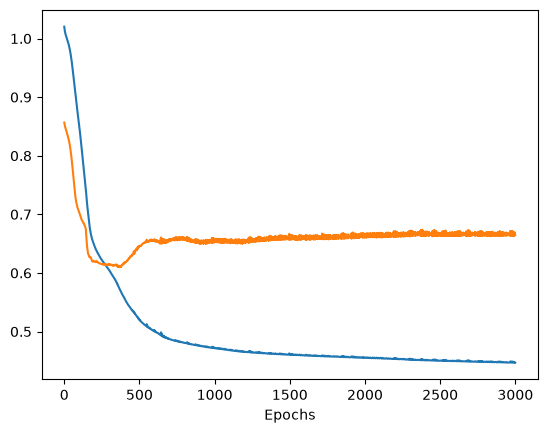

In [81]:
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

df = pd.read_csv('titanic.csv')

# separate out all columns where age is not null and where age is null
df_age_null = df[df['age'].isnull()]
df = df[df['age'].notnull()]

df = pd.get_dummies(df, columns=['sex'], drop_first=True, dtype=float) 
df.head()



# ----------------------------
# Split the dataframe
# ----------------------------

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)


# standard scaler
scaler = StandardScaler()
# apply scaler to the features
continuous = ['age', 'fare']

scaler = StandardScaler()
train_df[continuous] = scaler.fit_transform(train_df[continuous])
test_df[continuous] = scaler.transform(test_df[continuous])

import torch
# interesting twist is, let us predict the ages
X = torch.tensor(train_df.drop('age', axis=1).values, dtype=torch.float32)
y = torch.tensor(train_df['age'].values, dtype=torch.float32)
Xtest = torch.tensor(test_df.drop('age', axis=1).values, dtype=torch.float32)
ytest = torch.tensor(test_df['age'].values, dtype=torch.float32)
print(X.shape, y.shape)
y = y.view(-1, 1)
ytest = ytest.view(-1, 1)
print(X.shape, y.shape)
print(Xtest.shape, ytest.shape)
class TitanicAgeModel(torch.nn.Module):
    def __init__(self):
        super(TitanicAgeModel, self).__init__()
        self.fc1 = torch.nn.Linear(6, 64)
        self.fc2 = torch.nn.Linear(64, 32)
        self.fc3 = torch.nn.Linear(32, 16)
        self.fc4 = torch.nn.Linear(16, 4)
        self.fc5 = torch.nn.Linear(4, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = torch.relu(self.fc4(x))
        x = self.fc5(x)
        return x

model = TitanicAgeModel()
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=3*3e-3)

train_losses = []
test_losses = []


epochs = 3000

for epoch in range(epochs):
    # forward pass
    y_pred = model(X)
    loss = criterion(y_pred, y)
    train_losses.append(loss.item())
    model.eval()
    with torch.no_grad():
        test_loss = criterion(model(Xtest), ytest)
        test_losses.append(test_loss.item())
    model.train()
    # backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch) % 100 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, Test Loss: {test_loss.item():.4f}')

print("Training complete. final loss: ", loss.item(), " final test loss: ", test_loss.item())
import matplotlib.pyplot as plt
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epochs')

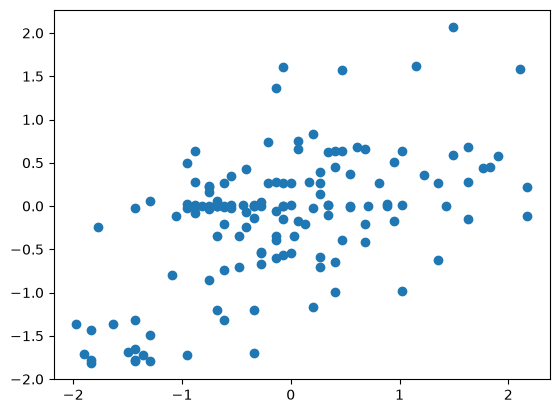

In [82]:
# predict ages for test set
model.eval()
age_predictions = model(Xtest).detach().numpy()

# plot age_predictions against the true ages
plt.scatter(ytest.numpy(), age_predictions)

In [84]:
# correlation between true ages and predicted ages
correlation = np.corrcoef(ytest.numpy().flatten(), age_predictions.flatten())[0, 1]
print("Correlation between true ages and predicted ages: ", correlation)

Correlation between true ages and predicted ages:  0.5448792819897537
